In [1]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/proj3-dataset/Medical_appointment_data.csv")




In [2]:
print(df.shape)
df.head()

(109593, 26)


,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
0,psychotherapy,17,F,yes,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
1,NaN,7,M,no,intellectual,ITAPEMA,morning,11.0,1,0,...,1,no_rain,cold,2020-01-01,0,0,0,0,0,0
2,speech therapy,16,M,no,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
3,speech therapy,14,M,yes,intellectual,Sarahside,afternoon,9.0,1,0,...,1,moderate,mild,2020-01-01,0,0,0,0,0,1
4,physiotherapy,8,M,no,motor,ITAJAÍ,morning,NaN,0,0,...,1,no_rain,mild,2020-01-01,0,0,0,0,0,0


In [3]:
print(df.dtypes)
df.isnull().sum()

specialty                       object
appointment_time                 int64
gender                          object
no_show                         object
disability                      object
place                           object
appointment_shift               object
age                            float64
under_12_years_old               int64
over_60_years_old                int64
patient_needs_companion          int64
average_temp_day               float64
average_rain_day               float64
max_temp_day                   float64
max_rain_day                   float64
rainy_day_before                 int64
storm_day_before                 int64
rain_intensity                  object
heat_intensity                  object
appointment_date_continuous     object
Hipertension                     int64
Diabetes                         int64
Alcoholism                       int64
Handcap                          int64
Scholarship                      int64
SMS_received             

,0
specialty,20127
appointment_time,0
gender,0
no_show,0
disability,16601
place,11539
appointment_shift,0
age,22960
under_12_years_old,0
over_60_years_old,0


In [4]:
print("Total duplicates:", df.duplicated().sum())

Total duplicates: 36


In [5]:
df[df.duplicated()]

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
1812,psychotherapy,17,M,no,NaN,NaN,afternoon,NaN,0,0,...,0,no_rain,heavy_cold,2020-02-05,0,0,0,0,0,0
5476,NaN,8,M,yes,NaN,NaN,morning,NaN,0,0,...,0,no_rain,heavy_cold,2020-02-14,0,0,0,0,0,0
5937,speech therapy,16,F,no,intellectual,ITAJAÍ,afternoon,NaN,0,0,...,1,no_rain,mild,2020-02-15,0,0,0,0,0,0
9906,NaN,8,M,no,NaN,NaN,morning,NaN,0,0,...,0,no_rain,heavy_cold,2020-02-27,0,0,0,0,0,0
9928,NaN,8,M,no,NaN,NaN,morning,NaN,0,0,...,0,no_rain,heavy_cold,2020-02-27,0,0,0,0,0,0
10037,NaN,8,M,no,NaN,NaN,morning,NaN,0,0,...,0,no_rain,heavy_cold,2020-02-27,0,0,0,0,0,0
11478,pedagogo,13,F,no,intellectual,ITAJAÍ,afternoon,11.0,1,0,...,1,no_rain,cold,2020-03-03,0,0,0,0,1,0
12492,NaN,8,M,no,NaN,NaN,morning,NaN,0,0,...,0,no_rain,heavy_cold,2020-03-05,0,0,0,0,0,0
19614,occupational therapy,13,F,no,NaN,NaN,afternoon,NaN,0,0,...,0,no_rain,heavy_cold,2020-04-01,0,0,0,0,0,0
19979,NaN,8,M,no,NaN,NaN,morning,NaN,0,0,...,1,no_rain,mild,2020-04-01,0,0,0,0,0,0


In [6]:
df.drop_duplicates(inplace=True)

#handling missing values

handling null age

In [7]:
df['age'].describe()


,age
count,86628.000000
mean,18.632544
std,17.667387
min,2.000000
25%,8.000000
50%,12.000000
75%,18.000000
max,110.000000


In [8]:
#checking missing age distribution
df[df['age'].isnull()][
    ['under_12_years_old','over_60_years_old']
].value_counts()

,,count
under_12_years_old,over_60_years_old,
0,0,16656
1,0,5402
0,1,855
1,1,16


In [9]:
# Under 12 flag but age >= 12
((df['under_12_years_old'] == 1) & (df['age'] >= 12)).sum()

np.int64(3956)

In [10]:
# Over 60 flag but age <= 60
((df['over_60_years_old'] == 1) & (df['age'] <= 60)).sum()

np.int64(1102)

In [11]:
df['age_missing'] = df['age'].isnull().astype(int)
df['age'] = df['age'].fillna(df['age'].median())

speciality

In [12]:
df['specialty'].value_counts(dropna=False)

,count
specialty,
psychotherapy,28642
speech therapy,22321
physiotherapy,21001
NaN,20100
occupational therapy,11318
pedagogo,3535
enf,1681
assist,635
sem especialidade,324


In [13]:
df['specialty'] = df['specialty'].fillna('Unknown')

In [14]:
df['specialty'].isnull().sum()

np.int64(0)

In [15]:
df.head()

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received,age_missing
0,psychotherapy,17,F,yes,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,no_rain,warm,2020-01-01,0,0,0,0,0,0,0
1,Unknown,7,M,no,intellectual,ITAPEMA,morning,11.0,1,0,...,no_rain,cold,2020-01-01,0,0,0,0,0,0,0
2,speech therapy,16,M,no,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,no_rain,warm,2020-01-01,0,0,0,0,0,0,0
3,speech therapy,14,M,yes,intellectual,Sarahside,afternoon,9.0,1,0,...,moderate,mild,2020-01-01,0,0,0,0,0,1,0
4,physiotherapy,8,M,no,motor,ITAJAÍ,morning,12.0,0,0,...,no_rain,mild,2020-01-01,0,0,0,0,0,0,1


handling null disability

In [16]:
df['disability'].unique()

array(['intellectual', 'motor', nan, ' '], dtype=object)

In [17]:
df['disability'].value_counts(dropna=False)

,count
disability,
intellectual,62847
motor,29720
NaN,16571
,419


In [18]:
df['disability'] = df['disability'].fillna('Unknown')
df['disability'] = df['disability'].replace('', 'unknown')
df['disability'] = df['disability'].replace(' ', 'unknown')

In [19]:
df['disability'].isnull().sum()

np.int64(0)

place null vla

In [20]:
df['place'].value_counts(dropna=False)

,count
place,
ITAJAÍ,20512
NaN,11509
B. CAMBORIU,6018
CAMBORIU,5523
NAVEGANTES,3901
...,...
New Taylorfort,1
Ellisland,1
East Jacobmouth,1


In [21]:
import numpy as np

df['place'] = df['place'].replace(' ', np.nan)
df['place'] = df['place'].fillna('Unknown')

Weather Columns missing values:

In [22]:
df[['average_temp_day',
    'average_rain_day',
    'max_temp_day',
    'max_rain_day']].isnull().sum()

,0
average_temp_day,2191
average_rain_day,2225
max_temp_day,2207
max_rain_day,2243


In [23]:
weather_cols = [
    'average_temp_day',
    'average_rain_day',
    'max_temp_day',
    'max_rain_day'
]

for col in weather_cols:
    df[col] = df[col].fillna(df[col].median())

In [24]:
df.isnull().sum()

,0
specialty,0
appointment_time,0
gender,0
no_show,0
disability,0
place,0
appointment_shift,0
age,0
under_12_years_old,0
over_60_years_old,0


In [25]:
df[df.select_dtypes(include='object').columns] = (
    df.select_dtypes(include='object')
      .apply(lambda x: x.str.strip().str.lower())
)

# EDA

In [26]:
df['no_show'].value_counts()

,count
no_show,
no,74726
yes,34831


In [27]:
df['no_show'].value_counts(normalize=True) * 100

,proportion
no_show,
no,68.207417
yes,31.792583


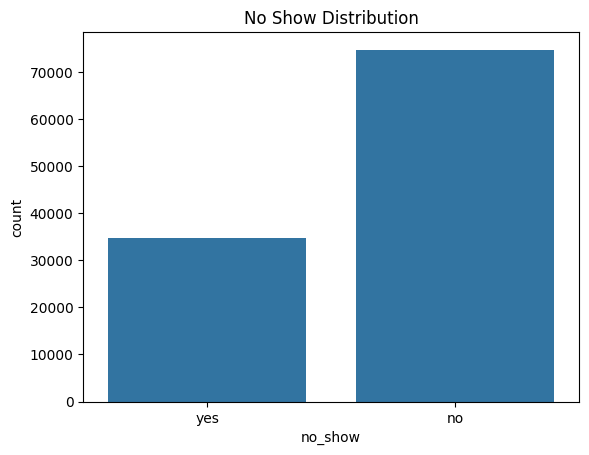

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='no_show')
plt.title("No Show Distribution")
plt.show()

In [29]:
df.describe()

,appointment_time,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received,age_missing
count,109557.000000,109557.000000,109557.000000,109557.000000,109557.000000,109557.000000,109557.000000,109557.000000,109557.000000,109557.000000,109557.000000,109557.000000,109557.000000,109557.000000,109557.000000,109557.000000,109557.000000,109557.000000
mean,12.121517,17.244430,0.446544,0.071351,0.519967,20.351774,0.180033,24.030276,2.010484,0.937558,0.937695,0.058107,0.023960,0.018547,0.009119,0.055122,0.311847,0.209288
std,3.281433,15.940181,0.497136,0.257411,0.499603,3.411576,0.412770,3.919775,4.315672,0.241958,0.241711,0.233946,0.152926,0.134921,0.095055,0.228219,0.463250,0.406802
min,7.000000,2.000000,0.000000,0.000000,0.000000,8.940000,0.000000,13.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,9.000000,0.000000,0.000000,0.000000,18.160000,0.000000,21.500000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,13.000000,12.000000,0.000000,0.000000,1.000000,20.600000,0.010000,23.900000,0.200000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,15.000000,18.000000,1.000000,0.000000,1.000000,22.650000,0.150000,26.700000,1.800000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,18.000000,110.000000,1.000000,1.000000,1.000000,28.010000,4.770000,35.400000,45.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


univariate analysis

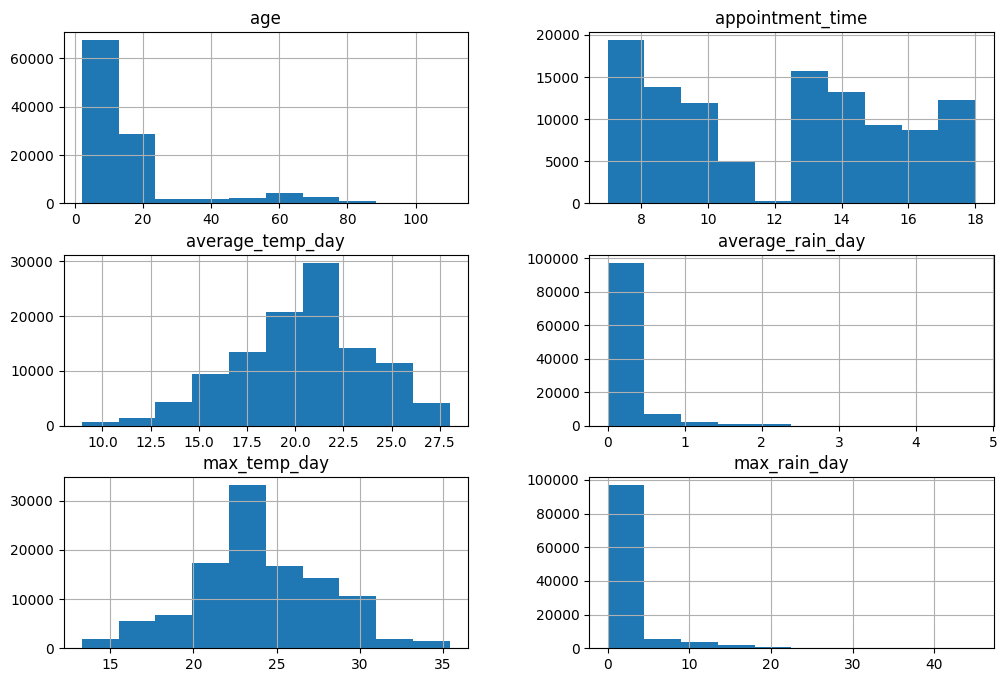

In [30]:
num_cols = [
    'age',
    'appointment_time',
    'average_temp_day',
    'average_rain_day',
    'max_temp_day',
    'max_rain_day'
]

df[num_cols].hist(figsize=(12,8))
plt.show()

In [31]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(df[col].value_counts())
    print("="*50)

specialty
psychotherapy           28642
speech therapy          22321
physiotherapy           21001
unknown                 20100
occupational therapy    11318
pedagogo                 3535
enf                      1681
assist                    635
sem especialidade         324
Name: count, dtype: int64
gender
m    82236
f    27074
i      247
Name: count, dtype: int64
no_show
no     74726
yes    34831
Name: count, dtype: int64
disability
intellectual    62847
motor           29720
unknown         16990
Name: count, dtype: int64
place
itajaí             20512
unknown            11509
b. camboriu         6018
camboriu            5523
navegantes          3901
                   ...  
new taylorfort         1
ellisland              1
east jacobmouth        1
hallburgh              1
irwinton               1
Name: count, Length: 26290, dtype: int64
appointment_shift
afternoon    59321
morning      50236
Name: count, dtype: int64
rain_intensity
no_rain     76381
moderate    16250
weak      

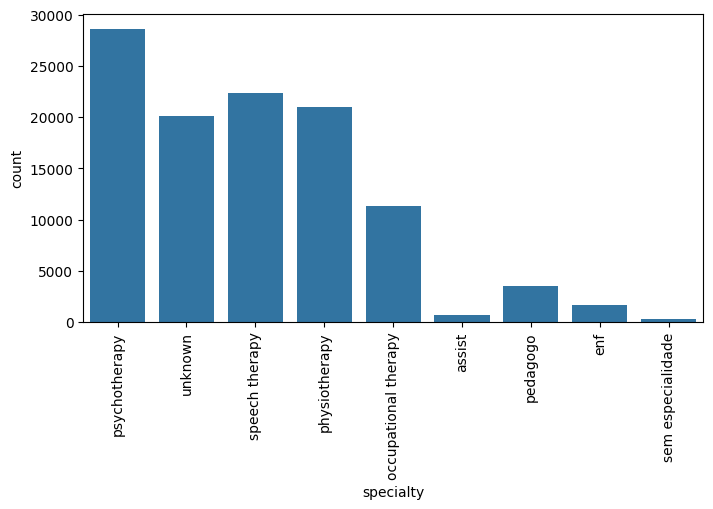

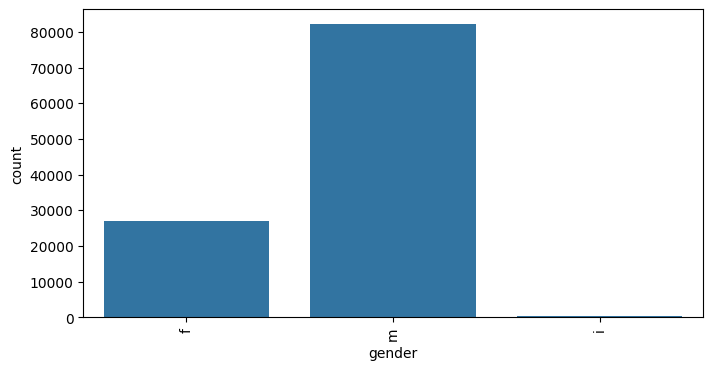

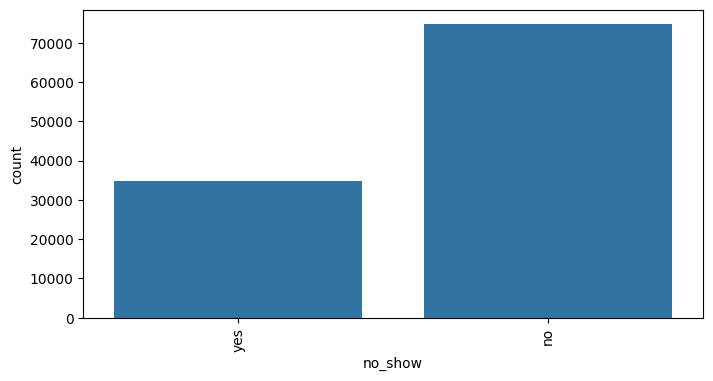

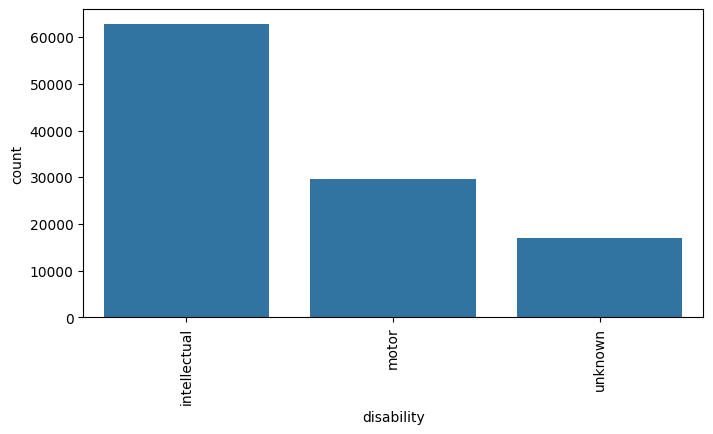

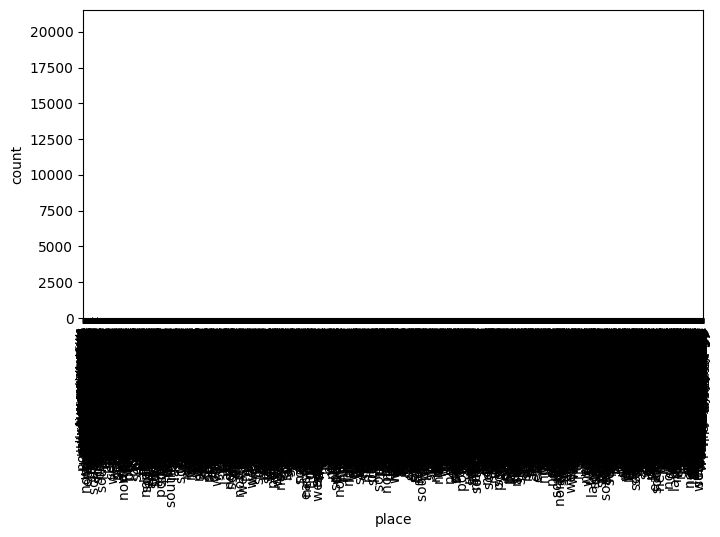

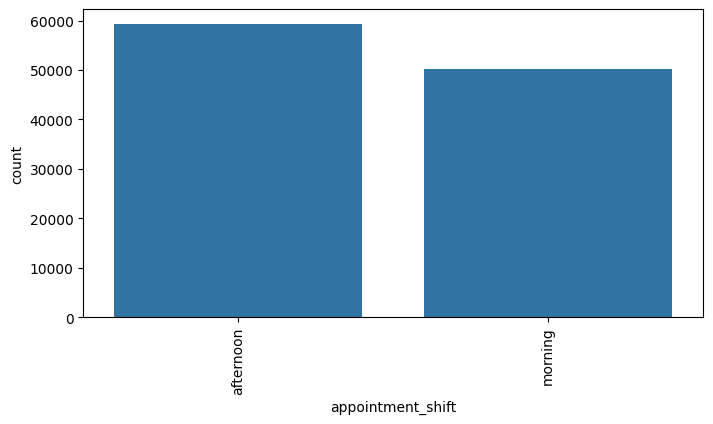

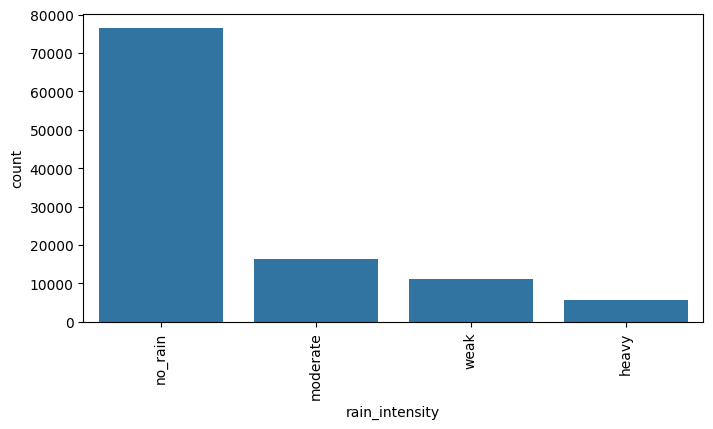

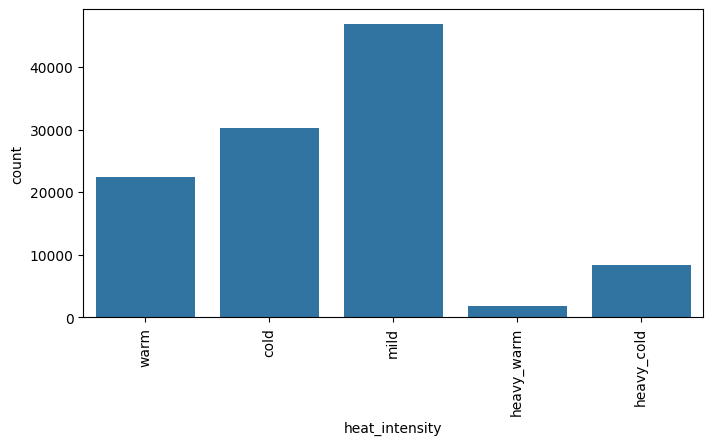

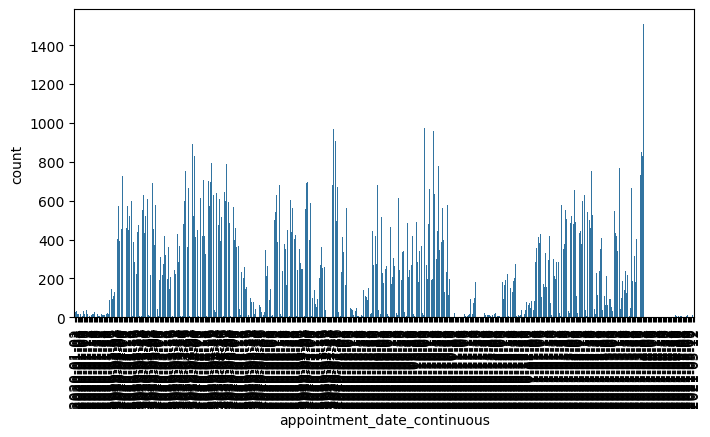

In [32]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=90)
    plt.show()

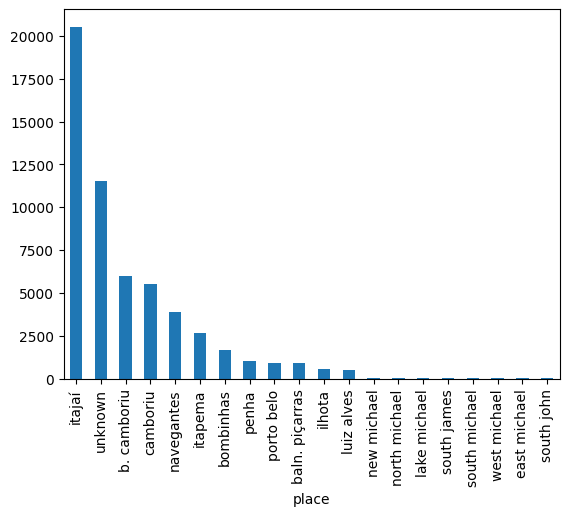

In [33]:
df['place'].value_counts().head(20).plot(
    kind='bar'
)

plt.show()

In [34]:


df['appointment_date_continuous'] = pd.to_datetime(
    df['appointment_date_continuous']
)

In [35]:
df['appointment_weekday'] = df['appointment_date_continuous'].dt.day_name()

In [36]:
df['appointment_weekday'].value_counts()

,count
appointment_weekday,
Thursday,18369
Friday,17024
Saturday,16968
Monday,16236
Tuesday,15536
Wednesday,14330
Sunday,11094


bi-variate analysis

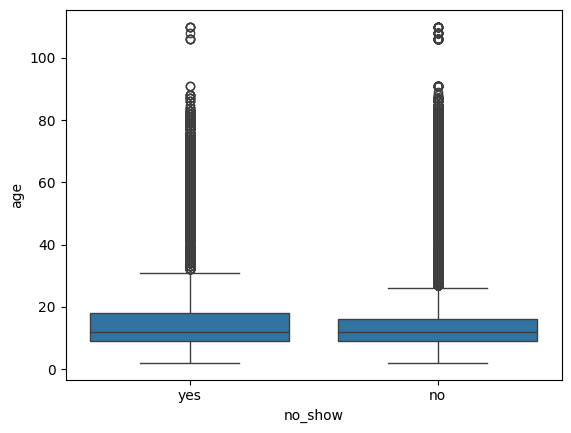

In [37]:
sns.boxplot(
    x='no_show',
    y='age',
    data=df
)

plt.show()

In [38]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 12, 18, 35, 60, 120],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

pd.crosstab(
    df['age_group'],
    df['no_show'],
    normalize='index'
) * 100

no_show,no,yes
age_group,,
Child,70.428830,29.571170
Teen,64.896585,35.103415
Young Adult,53.005520,46.994480
Adult,69.952012,30.047988
Senior,77.608102,22.391898


In [39]:
df['appointment_time'].value_counts().sort_index()

,count
appointment_time,
7,7864
8,11483
9,13804
10,11886
11,4964
12,264
13,15771
14,13205
15,9301


In [40]:
hour_noshow = pd.crosstab(
    df['appointment_time'],
    df['no_show'],
    normalize='index'
) * 100

hour_noshow

no_show,no,yes
appointment_time,,
7,68.387589,31.612411
8,67.255944,32.744056
9,67.944074,32.055926
10,60.987717,39.012283
11,75.020145,24.979855
12,81.818182,18.181818
13,69.317101,30.682899
14,69.390382,30.609618
15,73.766262,26.233738


In [41]:
pd.crosstab(
    df['SMS_received'],
    df['no_show'],
    normalize='index'
) * 100

no_show,no,yes
SMS_received,,
0,68.238009,31.761991
1,68.139909,31.860091


In [42]:
place_counts = df['place'].value_counts()

valid_places = place_counts[place_counts >= 50].index

df_place = df[df['place'].isin(valid_places)]

In [43]:
place_noshow = pd.crosstab(
    df_place['place'],
    df_place['no_show'],
    normalize='index'
) * 100

place_noshow['count'] = df_place['place'].value_counts()

place_noshow.sort_values('yes', ascending=False)

no_show,no,yes,count
place,,,
north michael,47.058824,52.941176,51
new michael,57.142857,42.857143,56
unknown,65.157703,34.842297,11509
luiz alves,86.424474,13.575526,523
ilhota,86.792453,13.207547,583
bombinhas,88.283538,11.716462,1707
porto belo,88.315789,11.684211,950
navegantes,89.489874,10.510126,3901
itapema,90.318949,9.681051,2665


In [44]:
pd.crosstab(
    df['rain_intensity'],
    df['no_show'],
    normalize='index'
) * 100

no_show,no,yes
rain_intensity,,
heavy,67.234190,32.765810
moderate,66.793846,33.206154
no_rain,68.685930,31.314070
weak,67.493286,32.506714


In [45]:

pd.crosstab(
    df['appointment_shift'],
    df['no_show'],
    normalize='index'
) * 100

no_show,no,yes
appointment_shift,,
afternoon,69.280693,30.719307
morning,66.940043,33.059957


In [46]:
pd.crosstab(
    df['gender'],
    df['no_show'],
    normalize='index'
)*100

no_show,no,yes
gender,,
f,66.307158,33.692842
i,82.591093,17.408907
m,68.789824,31.210176


In [47]:
for col in ['Hipertension','Diabetes','Alcoholism','Handcap','Scholarship']:
    print(col)
    print(pd.crosstab(df[col], df['no_show'], normalize='index')*100)
    print('-'*50)

Hipertension
no_show              no        yes
Hipertension                      
0             67.876074  32.123926
1             73.578385  26.421615
--------------------------------------------------
Diabetes
no_show          no        yes
Diabetes                      
0         68.104029  31.895971
1         72.419048  27.580952
--------------------------------------------------
Alcoholism
no_show            no        yes
Alcoholism                      
0           68.140432  31.859568
1           71.751969  28.248031
--------------------------------------------------
Handcap
no_show         no        yes
Handcap                      
0        68.197645  31.802355
1        69.269269  30.730731
--------------------------------------------------
Scholarship
no_show             no        yes
Scholarship                      
0            68.205529  31.794471
1            68.239775  31.760225
--------------------------------------------------


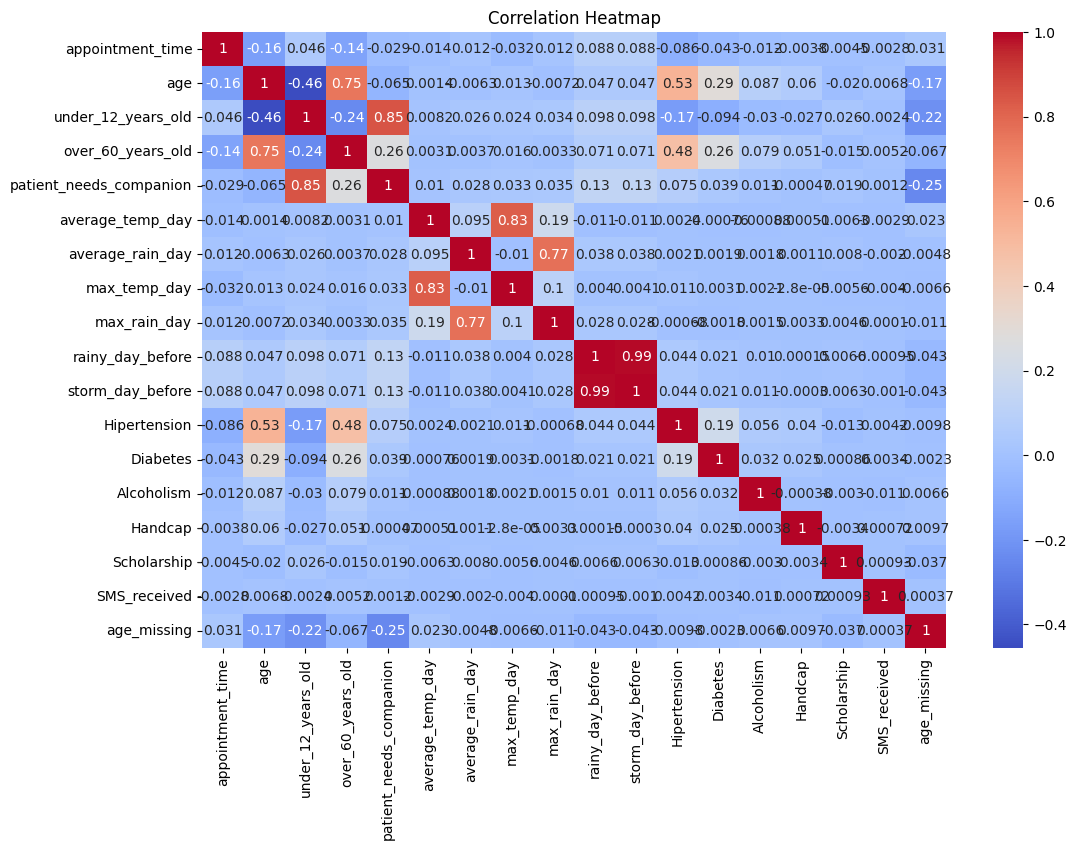

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.savefig('correlation_heatmap.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

#feature engineering

In [49]:
df['place'].nunique()

26290

In [50]:
df.head()

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received,age_missing,appointment_weekday,age_group
0,psychotherapy,17,f,yes,intellectual,lake marvinville,afternoon,9.0,1,0,...,2020-01-01,0,0,0,0,0,0,0,Wednesday,Child
1,unknown,7,m,no,intellectual,itapema,morning,11.0,1,0,...,2020-01-01,0,0,0,0,0,0,0,Wednesday,Child
2,speech therapy,16,m,no,intellectual,itajaí,afternoon,8.0,1,0,...,2020-01-01,0,0,0,0,0,0,0,Wednesday,Child
3,speech therapy,14,m,yes,intellectual,sarahside,afternoon,9.0,1,0,...,2020-01-01,0,0,0,0,0,1,0,Wednesday,Child
4,physiotherapy,8,m,no,motor,itajaí,morning,12.0,0,0,...,2020-01-01,0,0,0,0,0,0,1,Wednesday,Child


In [51]:
pd.DataFrame(
    sorted(df['place'].unique()),
    columns=['place']
).to_csv('unique_places.csv', index=False)

In [52]:
specialty_missing = (
    df['specialty'].isin(['unknown','sem especialidade'])
).astype(int)


In [53]:
df['under_12_years_old'] = (df['age'] < 12).astype(int)

df['over_60_years_old'] = (df['age'] >= 60).astype(int)

In [54]:
df['appointment_year'] = df['appointment_date_continuous'].dt.year
df['appointment_month'] = df['appointment_date_continuous'].dt.month
df['appointment_day'] = df['appointment_date_continuous'].dt.day
df['appointment_weekday'] = df['appointment_date_continuous'].dt.dayofweek

In [55]:
df['appointment_hour'] = df['appointment_time']

In [56]:
df.head(10)

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,Handcap,Scholarship,SMS_received,age_missing,appointment_weekday,age_group,appointment_year,appointment_month,appointment_day,appointment_hour
0,psychotherapy,17,f,yes,intellectual,lake marvinville,afternoon,9.0,1,0,...,0,0,0,0,2,Child,2020,1,1,17
1,unknown,7,m,no,intellectual,itapema,morning,11.0,1,0,...,0,0,0,0,2,Child,2020,1,1,7
2,speech therapy,16,m,no,intellectual,itajaí,afternoon,8.0,1,0,...,0,0,0,0,2,Child,2020,1,1,16
3,speech therapy,14,m,yes,intellectual,sarahside,afternoon,9.0,1,0,...,0,0,1,0,2,Child,2020,1,1,14
4,physiotherapy,8,m,no,motor,itajaí,morning,12.0,0,0,...,0,0,0,1,2,Child,2020,1,1,8
5,psychotherapy,13,m,no,intellectual,itajaí,afternoon,9.0,1,0,...,0,0,0,0,2,Child,2020,1,1,13
6,speech therapy,10,f,yes,motor,itajaí,morning,12.0,0,0,...,0,0,0,1,2,Child,2020,1,1,10
7,physiotherapy,7,m,no,motor,itajaí,morning,7.0,1,0,...,0,0,1,0,2,Child,2020,1,1,7
8,physiotherapy,16,m,yes,motor,stokesfort,afternoon,18.0,0,0,...,0,0,0,0,2,Teen,2020,1,1,16
9,occupational therapy,16,f,no,intellectual,itajaí,afternoon,12.0,0,0,...,0,0,0,1,2,Child,2020,1,1,16


In [57]:
df['appointment_shift'] = np.where(
    df['appointment_hour'] < 12,
    'Morning',
    'Afternoon'
)

In [58]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['specialty_encoded'] = le.fit_transform(df['specialty'])

In [59]:
top_places = df['place'].value_counts().nlargest(20).index

df['place_grouped'] = np.where(
    df['place'].isin(top_places),
    df['place'],
    'Other'
)

In [60]:
drop_cols = [
    'max_temp_day',
    'max_rain_day',
    'storm_day_before'
]

df = df.drop(columns=drop_cols)

In [61]:
binary_cols = [
    'Hipertension',
    'Diabetes',
    'Alcoholism',
    'Handcap',
    'SMS_received',
    'patient_needs_companion'
]

for col in binary_cols:
    df[col] = df[col].astype(int)

In [62]:
df.head(10)

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,SMS_received,age_missing,appointment_weekday,age_group,appointment_year,appointment_month,appointment_day,appointment_hour,specialty_encoded,place_grouped
0,psychotherapy,17,f,yes,intellectual,lake marvinville,Afternoon,9.0,1,0,...,0,0,2,Child,2020,1,1,17,5,Other
1,unknown,7,m,no,intellectual,itapema,Morning,11.0,1,0,...,0,0,2,Child,2020,1,1,7,8,itapema
2,speech therapy,16,m,no,intellectual,itajaí,Afternoon,8.0,1,0,...,0,0,2,Child,2020,1,1,16,7,itajaí
3,speech therapy,14,m,yes,intellectual,sarahside,Afternoon,9.0,1,0,...,1,0,2,Child,2020,1,1,14,7,Other
4,physiotherapy,8,m,no,motor,itajaí,Morning,12.0,0,0,...,0,1,2,Child,2020,1,1,8,4,itajaí
5,psychotherapy,13,m,no,intellectual,itajaí,Afternoon,9.0,1,0,...,0,0,2,Child,2020,1,1,13,5,itajaí
6,speech therapy,10,f,yes,motor,itajaí,Morning,12.0,0,0,...,0,1,2,Child,2020,1,1,10,7,itajaí
7,physiotherapy,7,m,no,motor,itajaí,Morning,7.0,1,0,...,1,0,2,Child,2020,1,1,7,4,itajaí
8,physiotherapy,16,m,yes,motor,stokesfort,Afternoon,18.0,0,0,...,0,0,2,Teen,2020,1,1,16,4,Other
9,occupational therapy,16,f,no,intellectual,itajaí,Afternoon,12.0,0,0,...,0,1,2,Child,2020,1,1,16,2,itajaí


In [63]:
cols_to_drop = [
    'appointment_date_continuous',
    'age_group',
    'specialty',
    'place'
]

df = df.drop(columns=cols_to_drop)

In [64]:
df.columns

Index(['appointment_time', 'gender', 'no_show', 'disability',
       'appointment_shift', 'age', 'under_12_years_old', 'over_60_years_old',
       'patient_needs_companion', 'average_temp_day', 'average_rain_day',
       'rainy_day_before', 'rain_intensity', 'heat_intensity', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship', 'SMS_received',
       'age_missing', 'appointment_weekday', 'appointment_year',
       'appointment_month', 'appointment_day', 'appointment_hour',
       'specialty_encoded', 'place_grouped'],
      dtype='object')

In [65]:
under12_inconsistency = df[
    ((df['age'] < 12) & (df['under_12_years_old'] == 0)) |
    ((df['age'] >= 12) & (df['under_12_years_old'] == 1))
]

print("Under 12 inconsistencies:", len(under12_inconsistency))

over60_inconsistency = df[
    ((df['age'] >= 60) & (df['over_60_years_old'] == 0)) |
    ((df['age'] < 60) & (df['over_60_years_old'] == 1))
]

print("Over 60 inconsistencies:", len(over60_inconsistency))

Under 12 inconsistencies: 0
Over 60 inconsistencies: 0


In [66]:
df.select_dtypes(include='object').columns

Index(['gender', 'no_show', 'disability', 'appointment_shift',
       'rain_intensity', 'heat_intensity', 'place_grouped'],
      dtype='object')

In [67]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'gender','no_show',
    'disability',
    'appointment_shift',
    'rain_intensity',
    'heat_intensity',
    'place_grouped'
]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [68]:
df.head(5)

,appointment_time,gender,no_show,disability,appointment_shift,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,...,Scholarship,SMS_received,age_missing,appointment_weekday,appointment_year,appointment_month,appointment_day,appointment_hour,specialty_encoded,place_grouped
0,17,0,1,0,0,9.0,1,0,1,23.18,...,0,0,0,2,2020,1,1,17,5,0
1,7,2,0,0,1,11.0,1,0,1,14.31,...,0,0,0,2,2020,1,1,7,8,8
2,16,2,0,0,0,8.0,1,0,1,21.61,...,0,0,0,2,2020,1,1,16,7,7
3,14,2,1,0,0,9.0,1,0,1,21.39,...,0,1,0,2,2020,1,1,14,7,0
4,8,2,0,1,1,12.0,0,0,0,20.15,...,0,0,1,2,2020,1,1,8,4,7


In [69]:
df.to_csv('medical_appointment_cleaned.csv', index=False)

# 1.For No-Show Prediction (Classification):


#Train-Test Split

In [204]:
import pandas as pd
data=pd.read_csv("/content/drive/MyDrive/proj3-dataset/medical_appointment_cleaned.csv")


In [205]:
data.columns

Index(['appointment_time', 'gender', 'no_show', 'disability',
       'appointment_shift', 'age', 'under_12_years_old', 'over_60_years_old',
       'patient_needs_companion', 'average_temp_day', 'average_rain_day',
       'rainy_day_before', 'rain_intensity', 'heat_intensity', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'Scholarship', 'SMS_received',
       'age_missing', 'appointment_weekday', 'appointment_year',
       'appointment_month', 'appointment_day', 'appointment_hour',
       'specialty_encoded', 'place_grouped'],
      dtype='object')

In [103]:
from sklearn.model_selection import train_test_split

x = data.drop('no_show', axis=1)
y = data['no_show']

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42,stratify=y)

In [104]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# logistic regression model

In [105]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train_scaled,y_train)


LogisticRegression()

In [106]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
y_pred=model.predict(x_test_scaled)
print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7036783497626871
              precision    recall  f1-score   support

           0       0.72      0.94      0.81     14946
           1       0.60      0.20      0.30      6966

    accuracy                           0.70     21912
   macro avg       0.66      0.57      0.55     21912
weighted avg       0.68      0.70      0.65     21912



Class 0 (No-show = 0)
Precision: 0.71
Recall: 0.94 ✅ (very strong)
F1-score: 0.81

model is very good at predicting patients who will NOT miss appointments


Class 1 (No-show = 1)
Precision:0.60 ,Recall:0.20 ❌ (very low),F1-score:0.30

model is failing to detect actual no-shows
Only 20% of real no-shows are being detected → this is a major issue for a medical prediction system.

In [107]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model with balanced class weights
model = LogisticRegression(class_weight='balanced',random_state=42,max_iter=1000)

# Train the model
model.fit(x_train_scaled, y_train)

# Predict on test data
y_pred = model.predict(x_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.653021175611537

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.66      0.72     14946
           1       0.47      0.65      0.54      6966

    accuracy                           0.65     21912
   macro avg       0.63      0.65      0.63     21912
weighted avg       0.69      0.65      0.66     21912


Confusion Matrix:
 [[9812 5134]
 [2469 4497]]


# randomforest model

In [108]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'  # helps with imbalance
)

# Train model
rf_model.fit(x_train, y_train)

# Predict
y_pred_rf = rf_model.predict(x_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7118930266520628

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.85      0.80     14946
           1       0.56      0.43      0.48      6966

    accuracy                           0.71     21912
   macro avg       0.66      0.64      0.64     21912
weighted avg       0.70      0.71      0.70     21912


Confusion Matrix:
 [[12635  2311]
 [ 4002  2964]]


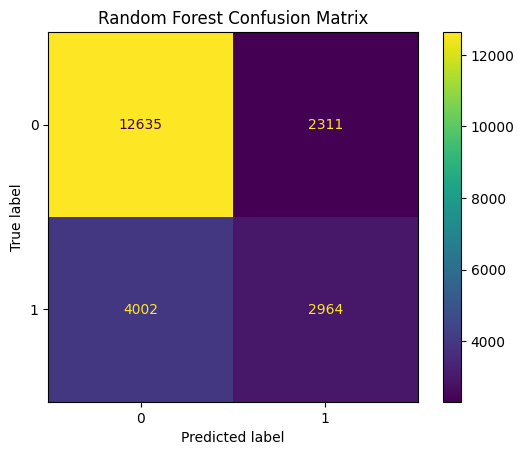

In [109]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    x_test,
    y_test
)

plt.title("Random Forest Confusion Matrix")
plt.show()

# xgboost

In [110]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create model
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

# Train model
xgb_model.fit(x_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(x_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.7267707192405988

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.82      0.80     14946
           1       0.58      0.52      0.55      6966

    accuracy                           0.73     21912
   macro avg       0.68      0.67      0.68     21912
weighted avg       0.72      0.73      0.72     21912


Confusion Matrix:
 [[12302  2644]
 [ 3343  3623]]


“XGBoost outperformed Logistic Regression and Random Forest in terms of overall accuracy (0.73) and F1-score (0.55 for class 1). While Logistic Regression achieved higher recall, XGBoost provided a better balance between precision and recall, making it the most suitable model for real-world deployment.”

In [111]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1])
)

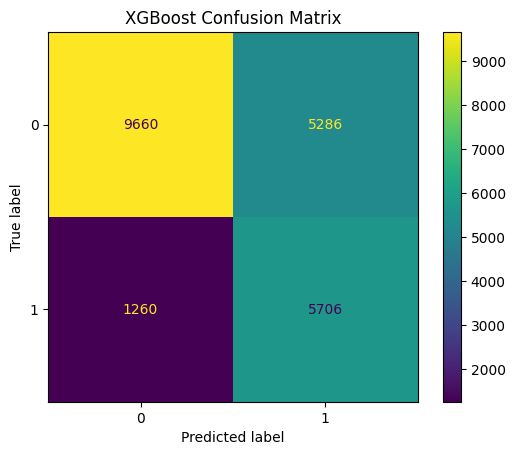

In [112]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

xgb_model.fit(x_train, y_train)

ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    x_test,
    y_test
)

plt.title("XGBoost Confusion Matrix")
plt.show()

In [113]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': xgb_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance.head(15))

                    Feature  Importance
26            place_grouped    0.500637
19              age_missing    0.120089
2                disability    0.061809
10         rainy_day_before    0.032864
12           heat_intensity    0.027204
7   patient_needs_companion    0.023167
25        specialty_encoded    0.021798
1                    gender    0.019175
8          average_temp_day    0.018244
0          appointment_time    0.018069
4                       age    0.016572
9          average_rain_day    0.016080
11           rain_intensity    0.014818
14                 Diabetes    0.012418
17              Scholarship    0.012402


In [114]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, xgb_model.predict_proba(x_test)[:,1])
print("ROC-AUC:", auc)

ROC-AUC: 0.7822370217921853


👉 Interpretation:

0.5 → random model (useless)
0.7 → acceptable model
0.75–0.85 → good model

0.85 → excellent model

✔model = good predictive power

# 2.For Demand Forecasting (Regression):


In [206]:
data.head(2)

,appointment_time,gender,no_show,disability,appointment_shift,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,rainy_day_before,rain_intensity,heat_intensity,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received,age_missing,appointment_weekday,appointment_year,appointment_month,appointment_day,appointment_hour,specialty_encoded,place_grouped
0,17,0,1,0,0,9.0,1,0,1,23.18,0.00,1,2,4,0,0,0,0,0,0,0,2,2020,1,1,17,5,0
1,7,2,0,0,1,11.0,1,0,1,14.31,0.02,1,2,0,0,0,0,0,0,0,0,2,2020,1,1,7,8,8


In [188]:
import pandas as pd

pd.set_option('display.max_columns', None)

df.head(2)

,appointment_time,gender,no_show,disability,appointment_shift,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,rainy_day_before,rain_intensity,heat_intensity,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received,age_missing,appointment_weekday,appointment_year,appointment_month,appointment_day,appointment_hour,specialty_encoded,place_grouped,appointment_date
0,17,0,1,0,0,9.0,1,0,1,23.18,0.00,1,2,4,0,0,0,0,0,0,0,2,2020,1,1,17,5,0,2020-01-01
1,7,2,0,0,1,11.0,1,0,1,14.31,0.02,1,2,0,0,0,0,0,0,0,0,2,2020,1,1,7,8,8,2020-01-01


In [207]:
#daily_feature
data['appointment_date'] = pd.to_datetime({
    'year': data['appointment_year'],
    'month': data['appointment_month'],
    'day': data['appointment_day']
})


In [208]:
print(daily_data['appointment_date'].nunique())

498


In [209]:
daily_data = data.groupby('appointment_date').agg(
    daily_appointments=('appointment_date', 'size'),
    average_temp_day=('average_temp_day', 'mean'),
    average_rain_day=('average_rain_day', 'mean'),
    rain_intensity=('rain_intensity', 'mean'),
    heat_intensity=('heat_intensity', 'mean')
).reset_index()

In [210]:
daily_data['appointment_date'] = pd.to_datetime(
    daily_data['appointment_date']
)

daily_data = daily_data.sort_values('appointment_date')

daily_data['day_of_week'] = daily_data['appointment_date'].dt.dayofweek
daily_data['month'] = daily_data['appointment_date'].dt.month
daily_data['quarter'] = daily_data['appointment_date'].dt.quarter
daily_data['week_of_year'] = (
    daily_data['appointment_date']
    .dt.isocalendar()
    .week
    .astype(int)
)
daily_data = daily_data.sort_values('appointment_date')

daily_data['lag_1'] = daily_data['daily_appointments'].shift(1)
daily_data['lag_7'] = daily_data['daily_appointments'].shift(7)
daily_data['lag_14'] = daily_data['daily_appointments'].shift(14)

daily_data['rolling_mean_7'] = (
    daily_data['daily_appointments']
    .shift(1)
    .rolling(7)
    .mean()
)

daily_data = daily_data.dropna()

In [211]:
print(daily_data.columns.tolist())

['appointment_date', 'daily_appointments', 'average_temp_day', 'average_rain_day', 'rain_intensity', 'heat_intensity', 'day_of_week', 'month', 'quarter', 'week_of_year', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7']


In [212]:
features = [
    'lag_1',
    'lag_7',
    'lag_14',
    'rolling_mean_7',
    'day_of_week',
    'month',
    'quarter',
    'week_of_year',
    'average_temp_day',
    'average_rain_day',
    'rain_intensity',
    'heat_intensity'
]

X = daily_data[features]

y = daily_data['daily_appointments']

In [213]:
train_size = int(len(daily_data) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

# randomforest model 1

In [214]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [215]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, predictions)

rmse = mean_squared_error(
    y_test,
    predictions
) ** 0.5

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 114.93756701030925
RMSE: 183.3093381926261
R2: 0.5826517942431824


# xg boost

In [216]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [217]:
daily_data['lag_30'] = daily_data['daily_appointments'].shift(30)

daily_data['rolling_mean_14'] = (
    daily_data['daily_appointments']
    .shift(1)
    .rolling(14)
    .mean()
)

daily_data['rolling_mean_30'] = (
    daily_data['daily_appointments']
    .shift(1)
    .rolling(30)
    .mean()
)

In [218]:
import numpy as np

daily_data['dow_sin'] = np.sin(
    2*np.pi*daily_data['day_of_week']/7
)

daily_data['dow_cos'] = np.cos(
    2*np.pi*daily_data['day_of_week']/7
)

daily_data['month_sin'] = np.sin(
    2*np.pi*daily_data['month']/12
)

daily_data['month_cos'] = np.cos(
    2*np.pi*daily_data['month']/12
)

In [219]:
daily_data['lag_30'] = daily_data['daily_appointments'].shift(30)

daily_data['rolling_mean_14'] = (
    daily_data['daily_appointments']
    .shift(1)
    .rolling(14)
    .mean()
)

daily_data['rolling_mean_30'] = (
    daily_data['daily_appointments']
    .shift(1)
    .rolling(30)
    .mean()
)

In [220]:
daily_data = daily_data.dropna()

In [221]:
features = [
    'lag_1',
    'lag_7',
    'lag_14',
    'lag_30',
    'rolling_mean_7',
    'rolling_mean_14',
    'rolling_mean_30',

    'day_of_week',
    'month',
    'quarter',
    'week_of_year',

    'dow_sin',
    'dow_cos',
    'month_sin',
    'month_cos',

    'average_temp_day',
    'average_rain_day',
    'rain_intensity',
    'heat_intensity'
]

In [224]:
X = daily_data[features]
y = daily_data['daily_appointments']

In [225]:
train_size = int(len(daily_data) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [226]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [227]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 123.20481872558594
RMSE: 198.33033523644335
R2: 0.5129579305648804


In [228]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})

print(
    importance.sort_values(
        'Importance',
        ascending=False
    ).head(15)
)

             Feature  Importance
16  average_rain_day    0.172928
1              lag_7    0.129156
17    rain_intensity    0.115101
18    heat_intensity    0.070655
14         month_cos    0.048178
10      week_of_year    0.048082
9            quarter    0.045809
4     rolling_mean_7    0.045350
0              lag_1    0.042792
15  average_temp_day    0.042593
7        day_of_week    0.040918
8              month    0.040645
5    rolling_mean_14    0.029830
12           dow_cos    0.027101
11           dow_sin    0.026333


In [229]:
baseline_pred = X_test['lag_7']
print("Baseline R2:", r2_score(y_test, baseline_pred))

Baseline R2: -0.5388448240657351


# random forest model2

In [231]:
print("Specialties:", df['specialty_encoded'].nunique())
print("Places:", df['place_grouped'].nunique())

Specialties: 9
Places: 21


In [232]:
specialty_daily = pd.crosstab(
    df['appointment_date'],
    df['specialty_encoded']
)

specialty_daily.columns = [
    f'specialty_{col}_count'
    for col in specialty_daily.columns
]

specialty_daily = specialty_daily.reset_index()

specialty_daily.head()

,appointment_date,specialty_0_count,specialty_1_count,specialty_2_count,specialty_3_count,specialty_4_count,specialty_5_count,specialty_6_count,specialty_7_count,specialty_8_count
0,2020-01-01,1,0,3,0,6,7,0,6,2
1,2020-01-02,0,0,4,3,7,12,0,4,3
2,2020-01-03,0,0,3,1,5,3,0,4,2
3,2020-01-04,1,1,0,2,3,6,0,1,2
4,2020-01-05,1,0,2,0,2,3,0,2,5


In [233]:
daily_data = daily_data.merge(
    specialty_daily,
    on='appointment_date',
    how='left'
)

In [234]:
[c for c in daily_data.columns if c.startswith('specialty_')]

['specialty_0_count',
 'specialty_1_count',
 'specialty_2_count',
 'specialty_3_count',
 'specialty_4_count',
 'specialty_5_count',
 'specialty_6_count',
 'specialty_7_count',
 'specialty_8_count']

In [ ]:
place_daily = pd.crosstab(
    df['appointment_date'],
    df['place_grouped']
)

place_daily.columns = [
    f'place_{col}_count'
    for col in place_daily.columns
]

place_daily = place_daily.reset_index()

place_daily.head()

In [ ]:
daily_data = daily_data.merge(
    place_daily,
    on='appointment_date',
    how='left'
)

In [235]:
specialty_cols = [
    col for col in daily_data.columns
    if col.startswith('specialty_')
]

place_cols = [
    col for col in daily_data.columns
    if col.startswith('place_')
]

print("Specialty Features:", len(specialty_cols))
print("Place Features:", len(place_cols))

Specialty Features: 9
Place Features: 0


In [236]:
features = [
    'lag_1',
    'lag_7',
    'lag_14',
    'lag_30',
    'rolling_mean_7',
    'rolling_mean_14',
    'rolling_mean_30',

    'day_of_week',
    'month',
    'quarter',
    'week_of_year',

    'dow_sin',
    'dow_cos',
    'month_sin',
    'month_cos',

    'average_temp_day',
    'average_rain_day',
    'rain_intensity',
    'heat_intensity'
]

features += specialty_cols
features += place_cols

In [237]:
X = daily_data[features]
y = daily_data['daily_appointments']

train_size = int(len(daily_data) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [238]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [239]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(
    y_test,
    predictions
) ** 0.5

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 13.822593406593404
RMSE: 66.26241012788505
R2: 0.9456346000901559


In [241]:
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    # Filter out cases where y_true is 0 to avoid division by zero
    non_zero_indices = y_true != 0
    if not np.any(non_zero_indices):
        return np.nan # Or raise an error, depending on desired behavior for all zeros

    y_true_filtered = y_true[non_zero_indices]
    y_pred_filtered = y_pred[non_zero_indices]

    return np.mean(np.abs((y_true_filtered - y_pred_filtered) / y_true_filtered)) * 100

mape = mean_absolute_percentage_error(y_test, predictions)
print(f"MAPE: {mape:.2f}%")

MAPE: 34.35%


In [240]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance.head(20))

              Feature  Importance
24  specialty_5_count    0.686014
27  specialty_8_count    0.182214
23  specialty_4_count    0.073255
26  specialty_7_count    0.048976
21  specialty_2_count    0.005907
18     heat_intensity    0.000295
5     rolling_mean_14    0.000262
6     rolling_mean_30    0.000247
16   average_rain_day    0.000244
4      rolling_mean_7    0.000239
22  specialty_3_count    0.000194
2              lag_14    0.000180
0               lag_1    0.000172
15   average_temp_day    0.000168
17     rain_intensity    0.000166
3              lag_30    0.000155
1               lag_7    0.000155
14          month_cos    0.000142
20  specialty_1_count    0.000137
25  specialty_6_count    0.000135
